In [ ]:
"""
Packages needed to install for first time setup (uncomment and run in terminal):
"""
# !uv pip install dash
# !uv pip install pandas
# !uv pip install scipy
# !uv pip install matplotlib
# !uv pip install onnxruntime
# !uv pip install openpyxl

In [35]:
"""
Step 1. Load data
"""
from utils.trial import load_trial

# Edit these values
SUBJECTS_DIR = "subjects"
SUBJECT_NAME = "ncbc_s18"
TRIAL_NAME = "m3"
RESULTS_FILE = "IMU_data_RevB_ncbc_s18_m3_t1.csv"
# RESULTS_FILE = "results.json"
# ================================

trial = load_trial(SUBJECTS_DIR, SUBJECT_NAME, TRIAL_NAME)
SUBJECT_WEIGHT = trial.subject_weight

print('Subject Name: ', SUBJECT_NAME)
print('Subject Mass (kg): ', SUBJECT_WEIGHT)

sensors = trial.load_sensors()
treadmill_unaligned = trial.load_treadmill()

Assigned sensor IDs for trial m3: {'left': 2, 'right': 3, 'waist': 1}
Subject Name:  ncbc_s18
Subject Mass (kg):  60
subjects\ncbc_s18\trials\m3\IMU_data_RevB_ncbc_s18_m3_t1.csv
Raw sampling rate: 138.55525961661948
Raw sampling rate: 138.48267082097928
Raw sampling rate: 138.22813365496293
Sampling Freuquency (Hz): 1000


In [36]:
# sensors
# # treadmill_unaligned

# # determine effective sampling rate for sensors
# prints effective sampling rate
for sensor in [sensors.left_df, sensors.right_df, sensors.waist_df]:
    elapsed_time = sensor.time.iloc[-1] - sensor.time.iloc[0]
    num_samples = len(sensor)
    samp_rate = num_samples / elapsed_time
    print(f'Effective sampling rate: {samp_rate}')

Effective sampling rate: 100.00558378468926
Effective sampling rate: 100.00558378468926
Effective sampling rate: 100.00558409649318


In [37]:
round(max(sensors.left_df['time']))

179

In [38]:
round(max(treadmill_unaligned.right_df['time']))

167

Text(0, 0.5, 'BW')

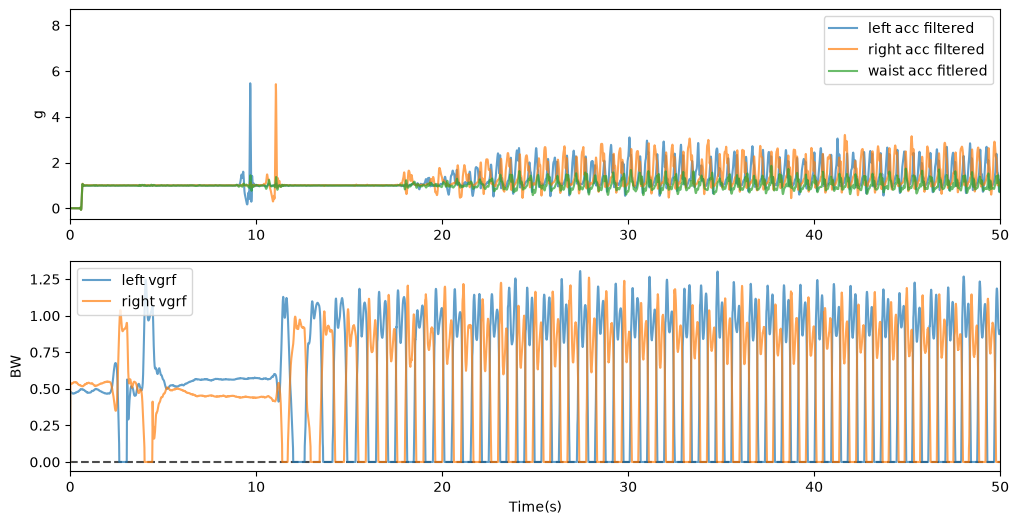

In [39]:
import matplotlib.pyplot as plt

A1 = 0.7

plt.figure(figsize=(12, 6))
ax1 = plt.subplot(2, 1, 1)
ax2 = plt.subplot(2, 1, 2)

ax1.plot(sensors.left_df['time'], 
         sensors.left_df['accel_filtered'], 
         label='left acc filtered', alpha=A1)
ax1.plot(sensors.right_df['time'], 
         sensors.right_df['accel_filtered'], 
         label='right acc filtered', alpha=A1)
ax1.plot(sensors.waist_df['time'], 
         sensors.waist_df['accel_filtered'], 
         label='waist acc fitlered', alpha=A1)


ax2.axhline(0, color='k', linestyle='--', alpha=A1)
ax2.plot(treadmill_unaligned.left_df['time'], 
         treadmill_unaligned.left_df['vgrf'], 
         label='left vgrf', alpha=A1)
ax2.plot(treadmill_unaligned.right_df['time'], 
         treadmill_unaligned.right_df['vgrf'], 
         label='right vgrf', alpha=A1)

zoom = True
if zoom: 
    start = 0
    end = 50
    ax1.set_xlim([start, end])
    ax2.set_xlim([start, end])
    # ax1.set_xlim([186, 216])
    # ax2.set_xlim([170, 200])

ax1.legend()
ax2.legend()
ax2.set_xlabel('Time(s)')
ax1.set_ylabel('g')
ax2.set_ylabel('BW')

In [40]:
"""
Step 2. Use the alignment tool to find signal offsets.
Only uncomment one side at a time.
"""
from utils.viz import visually_align_signal
# Uncomment below to align left ankle and left force signals
SENSOR_SIGNAL = sensors.left_df['accel_filtered']
TREADMILL_SIGNAL = treadmill_unaligned.left_df['vgrf']

visually_align_signal(SENSOR_SIGNAL, TREADMILL_SIGNAL)

In [ ]:
raise StopIteration

In [41]:
# Uncomment below to align right ankle and right force signals
SENSOR_SIGNAL = sensors.right_df['accel_filtered']
TREADMILL_SIGNAL = treadmill_unaligned.right_df['vgrf'] 
visually_align_signal(SENSOR_SIGNAL, TREADMILL_SIGNAL)

In [ ]:
raise StopIteration

In [42]:
"""
Step 3. Align sensor and treadmill signals.

Use the above cell to visually determine offsets for the treadmill signals.
After you do that, update the values of LEFT_VGRF_OFFSET and RIGHT_VGRF_OFFSET.
"""

import pandas as pd
from utils.treadmill import TreadmillData

LEFT_VGRF_OFFSET = 657     # INPUT VALUE FROM STEP 2!
RIGHT_VGRF_OFFSET = 659     # INPUT VALUE FROM STEP 2!

def apply_offset(treadmill_df: pd.DataFrame, offset: int):
    """
    Applies an offset to treadmill_df
    """
    if offset < 0:
        out_df = treadmill_df.iloc[-offset:]
    elif offset > 0:
        padding = pd.DataFrame({'time': [0]*offset, 'vgrf': [0]*offset})
        out_df = pd.concat([padding, treadmill_df])
    else:
        out_df = treadmill_df
    return out_df.reset_index(drop=True)

left_df = apply_offset(treadmill_unaligned.left_df, LEFT_VGRF_OFFSET)
right_df = apply_offset(treadmill_unaligned.right_df, RIGHT_VGRF_OFFSET)

treadmill = TreadmillData(left_df, right_df)


--- DETECTED STRIKE INDICES ---
Total Raw Accel Strikes Found: 166
First 10 Accel Strikes:        [ 961 1917 2067 2191 2301 2403 2504 2607 2707 2810]
Total Raw vGRF Strikes Found:  166
First 10 vGRF Strikes:         [ 961 1917 2067 2191 2301 2403 2504 2607 2707 2810]
Total MATCHED Pairs Saved:     166
First 5 Matched Pairs (A, V):  [(np.int64(961), np.int64(961)), (np.int64(1917), np.int64(1917)), (np.int64(2067), np.int64(2067)), (np.int64(2191), np.int64(2191)), (np.int64(2301), np.int64(2301))]
---------------------------------



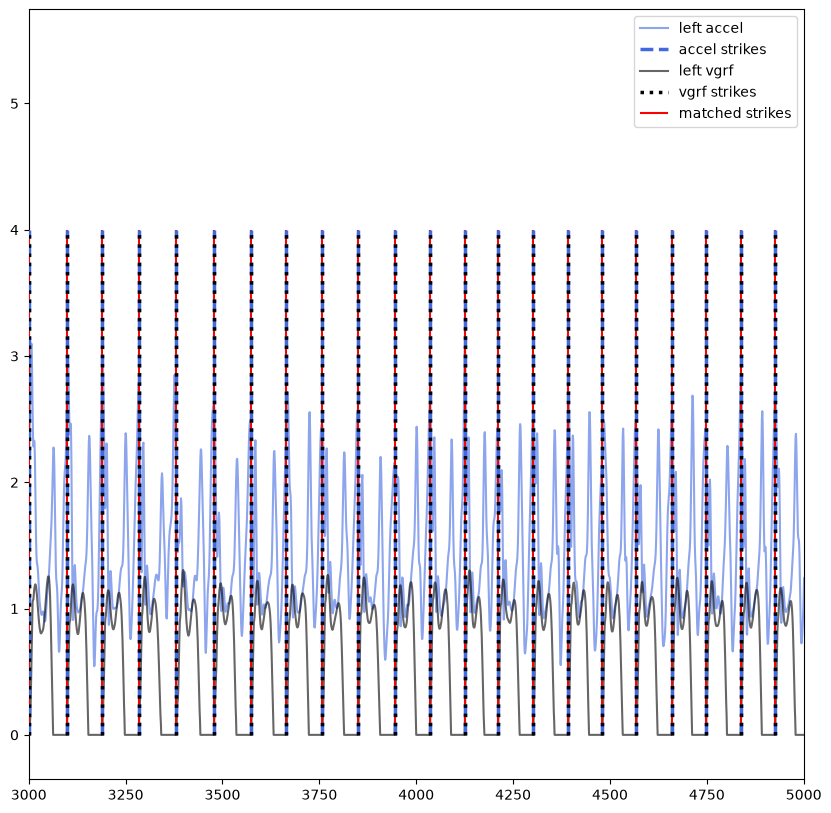

In [43]:
"""
Step 3. Extract strike indices and stances from the left.
"""
import matplotlib.pyplot as plt
from operator import itemgetter
from utils.stance import parse_and_match_stances, StanceAnalyzer
from utils.config import PipelineConfig

# You can uncomment and change the config to see how it affects the results.
#  See all parameters in utils/config.py

config = PipelineConfig(
    accel_peak_params={
        'height': 1.2, # amplitude threshold for peak detection (g)
        'prominence': 0.5, # how much a peak must stand out from the surrounding signal (g)
        'width': 1.0, # min width of peak (frames)
        'distance': 10 # min distance between peaks (frames), stride takes 60-100 frames
    },
    jerk_peak_params={
        'height': 0.0,
        'prominence': 0.1
    },
    jerk_window_size=50,
    stance_matching_time_threshold=10, # max time difference between accel strike and vgrf strike for them to be considered a match (frames)
    accel_filters=[],
    vgrf_filters=[],
    min_stance_size=80,
    max_stance_size=140 # max number of frames in a stance, incresae to 160-180 for clinical populations
)

left_strikes, left_stances, debug = parse_and_match_stances(
    sensors.left_df['accel_filtered'],
    sensors.left_df['accel'],
    sensors.waist_df['accel_filtered'],
    treadmill.left_df['vgrf'],
    config # <--- Uncomment to use your own config
)

SA = StanceAnalyzer(config=config)
left_accel_strikes, left_waist_accel_stances = SA.extract_sensor_stances(
                                    leg_accel = sensors.left_df['accel_filtered'], 
                                    leg_accel_unfiltered = sensors.left_df['accel'], 
                                    waist_accel = sensors.waist_df['accel_filtered'], 
                                    )

print("\n--- DETECTED STRIKE INDICES ---")
print(f"Total Raw Accel Strikes Found: {len(debug['accel_strikes'])}")
print(f"First 10 Accel Strikes:        {debug['accel_strikes'][:10]}")
print(f"Total Raw vGRF Strikes Found:  {len(debug['vgrf_strikes'])}")
print(f"First 10 vGRF Strikes:         {debug['vgrf_strikes'][:10]}")
print(f"Total MATCHED Pairs Saved:     {len(left_strikes)}")
print(f"First 5 Matched Pairs (A, V):  {left_strikes[:5]}")
print("---------------------------------\n")

# Plt Plot accel (Make the wave slightly transparent using alpha)
plt.figure(figsize=(10,10))
plt.plot(sensors.left_df['accel_filtered'], color='royalblue', alpha=0.6, label='left accel')

# Change to a contrasting color (e.g., orange or darkorange), make it thick, and pull to the front
plt.vlines(debug['accel_strikes'], 0, 4, color='royalblue', linestyle='--', linewidth=2.5, zorder=4, label='accel strikes')

# Plot vgrf
plt.plot(treadmill.left_df['vgrf'], color='black', alpha=0.6, label='left vgrf')

# Change to a contrasting color (e.g., green or purple) so it doesn't hide inside the black line
plt.vlines(debug['vgrf_strikes'], 0, 4, color='black', linestyle=':', linewidth=2.5, zorder=5, label='vgrf strikes')

# Plot matched strikes
plt.vlines(list(map(itemgetter(0), left_strikes)), 0, 4, color='red', linewidth=1.5, zorder=3, label='matched strikes')

# show plot
plt.xlim(3000,5000)
plt.legend()
plt.show()


# NOTE: Dropping filters and increasing stance_matching_time_threshold from 5 -> 10
# will cause more strikes to be matched.

In [ ]:
# raise StopIteration


--- DETECTED STRIKE INDICES ---
Total Raw Accel Strikes Found: 166
First 10 Accel Strikes:        [ 659 1828 2000 2131 2248 2357 2458 2558 2659 2760]
Total Raw vGRF Strikes Found:  166
First 10 vGRF Strikes:         [ 659 1828 2000 2131 2248 2357 2458 2558 2659 2760]
Total MATCHED Pairs Saved:     166
First 5 Matched Pairs (A, V):  [(np.int64(659), np.int64(659)), (np.int64(1828), np.int64(1828)), (np.int64(2000), np.int64(2000)), (np.int64(2131), np.int64(2131)), (np.int64(2248), np.int64(2248))]
---------------------------------



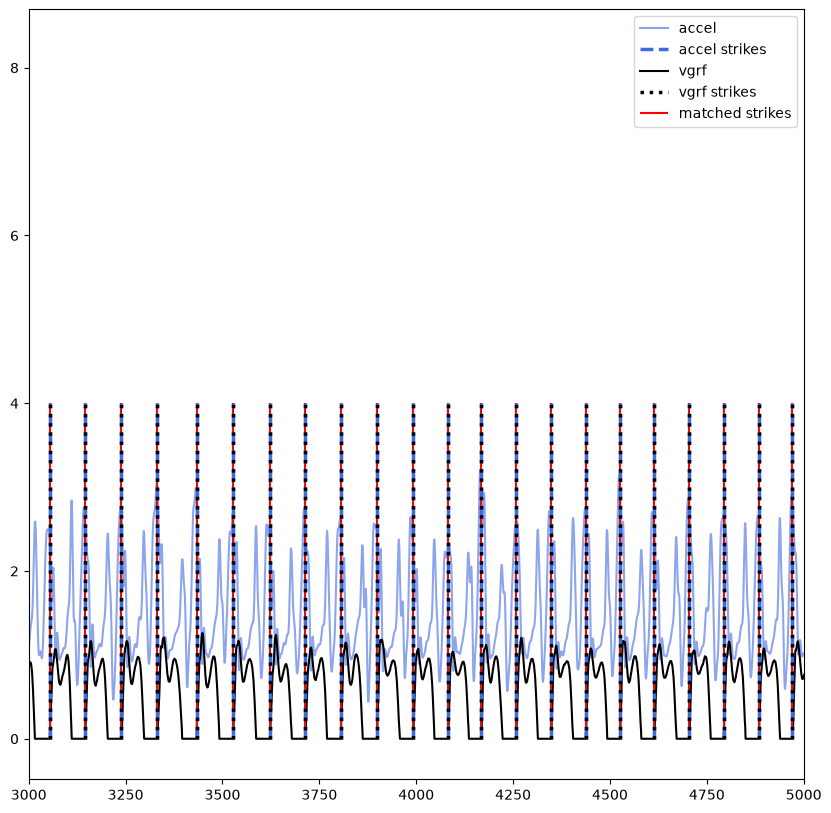

In [46]:
"""
Step 4. Extract strike indices and stances from the right.
"""

import matplotlib.pyplot as plt
from operator import itemgetter
from utils.stance import parse_and_match_stances, StanceAnalyzer
from utils.config import PipelineConfig

# You can uncomment and change the config to see how it affects the results.
#  See all parameters in utils/config.py

config = PipelineConfig(
    accel_peak_params={
        'height': 1.0, # amplitude threshold for peak detection
        'prominence': 0.3,
        'width': 5.0, # 
        'distance': 10
    },
    jerk_peak_params={
        'height': 0.0,
        'prominence': 0.1
    },
    jerk_window_size=50,
    stance_matching_time_threshold=10,
    accel_filters=[],
    vgrf_filters=[],
    min_stance_size=80,
    max_stance_size=140
)


right_strikes, right_stances, debug = parse_and_match_stances(
    sensors.right_df['accel_filtered'],
    sensors.right_df['accel'],
    sensors.waist_df['accel_filtered'],
    treadmill.right_df['vgrf'],
    config # <--- Uncomment to use your own config
)

# SA = StanceAnalyzer(config=config)
# right_accel_strikes, right_waist_accel_stances = SA.extract_sensor_stances(
#                                     leg_accel = sensors.right_df['accel_filtered'], 
#                                     leg_accel_unfiltered = sensors.right_df['accel'], 
#                                     waist_accel = sensors.waist_df['accel_filtered'], 
#                                     )

print("\n--- DETECTED STRIKE INDICES ---")
print(f"Total Raw Accel Strikes Found: {len(debug['accel_strikes'])}")
print(f"First 10 Accel Strikes:        {debug['accel_strikes'][:10]}")
print(f"Total Raw vGRF Strikes Found:  {len(debug['vgrf_strikes'])}")
print(f"First 10 vGRF Strikes:         {debug['vgrf_strikes'][:10]}")
print(f"Total MATCHED Pairs Saved:     {len(right_strikes)}")
print(f"First 5 Matched Pairs (A, V):  {right_strikes[:5]}")
print("---------------------------------\n")

# # Plot accel
plt.figure(figsize=(10,10))
plt.plot(sensors.right_df['accel_filtered'], color='royalblue',alpha=0.6, label='accel')
plt.vlines(debug['accel_strikes'], 0, 4, color='royalblue', linestyle='--', linewidth=2.5, zorder=4, label='accel strikes')

# # Plot vgrf
plt.plot(treadmill.right_df['vgrf'], color='black', label='vgrf')
plt.vlines(debug['vgrf_strikes'], 0, 4, color='black', linestyle=':', linewidth=2.5, zorder=5, label='vgrf strikes')

# # Plot matched strikes
plt.vlines(list(map(itemgetter(0), right_strikes)), 0, 4, color='red', linewidth=1.5, zorder=3, label='matched strikes')

# show plot
plt.xlim(3000, 5000)
plt.legend()
plt.show()

# NOTE: This side looks like it has good peak detection, but the strikes between the treadmill and sensors
# are not matching up.

In [ ]:
# for i in range(len(right_waist_accel_stances)):

#     plt.plot(right_waist_accel_stances[i])
# plt.plot(right_accel_stances[10][1])

In [47]:
"""
Step 5. Merge both sides and run through the model.
"""
import csv
import os
from utils.predict import predict_stance
from utils.output import make_peak_results, make_stance_results

RESULTS_DIR = f'results/{SUBJECT_NAME}/{TRIAL_NAME}' # Edit me!

REF_PEAKS_FILE = os.path.join(RESULTS_DIR, 'reference_peaks.xlsx')
PRED_PEAKS_FILE = os.path.join(RESULTS_DIR, 'pred_peaks.xlsx')
REF_STANCES_FILE_LEFT = os.path.join(RESULTS_DIR, 'reference_waveforms_L.xlsx')
REF_STANCES_FILE_RIGHT = os.path.join(RESULTS_DIR, 'reference_waveforms_R.xlsx')
PRED_STANCES_FILE_LEFT = os.path.join(RESULTS_DIR, 'pred_wavevforms_L.xlsx')
PRED_STANCES_FILE_RIGHT = os.path.join(RESULTS_DIR, 'pred_waveforms_R.xlsx')

if os.path.exists(RESULTS_DIR):
    print(f"A directory called {RESULTS_DIR}/ already exists. Overwriting files in it.")
else:
    os.makedirs(RESULTS_DIR)

left_accel_stances = list(map(itemgetter(0), left_stances)) 
left_vgrf_stances = list(map(itemgetter(1), left_stances))
right_accel_stances = list(map(itemgetter(0), right_stances))
right_vgrf_stances = list(map(itemgetter(1), right_stances))

# Use the MLP model to predict vGRF stances from accel stances
left_vgrf_pred_stances = list(map(predict_stance, left_accel_stances))
right_vgrf_pred_stances = list(map(predict_stance, right_accel_stances))


# Create reference and predicted peak results
ref_peak_results = make_peak_results(left_vgrf_stances, right_vgrf_stances)
ref_peak_results.to_excel(REF_PEAKS_FILE, index=False)

pred_peak_results = make_peak_results(left_vgrf_pred_stances, right_vgrf_pred_stances)
pred_peak_results.to_excel(PRED_PEAKS_FILE, index=False)

# Create reference and predicted stance (waveform) results
left_vgrf_stances = pd.DataFrame(left_vgrf_stances)
left_vgrf_stances_T = left_vgrf_stances.T
right_vgrf_stances = pd.DataFrame(right_vgrf_stances)
right_vgrf_stances_T = right_vgrf_stances.T

left_vgrf_results = pd.DataFrame(left_vgrf_stances_T)
left_vgrf_results.to_excel(REF_STANCES_FILE_LEFT, index=False)
right_vgrf_results = pd.DataFrame(right_vgrf_stances_T)
right_vgrf_results.to_excel(REF_STANCES_FILE_RIGHT, index=False)

left_vgrf_pred_stances = pd.DataFrame(left_vgrf_pred_stances)
left_vgrf_pred_stances_T = left_vgrf_pred_stances.T
right_vgrf_pred_stances = pd.DataFrame(right_vgrf_pred_stances)
right_vgrf_pred_stances_T = right_vgrf_pred_stances.T

left_pred_waveform_results = pd.DataFrame(left_vgrf_pred_stances_T)
left_pred_waveform_results.to_excel(PRED_STANCES_FILE_LEFT, index=False)
right_pred_waveform_results = pd.DataFrame(right_vgrf_pred_stances_T)
right_pred_waveform_results.to_excel(PRED_STANCES_FILE_RIGHT, index=False)

NameError: name 'right_waist_accel_stances' is not defined

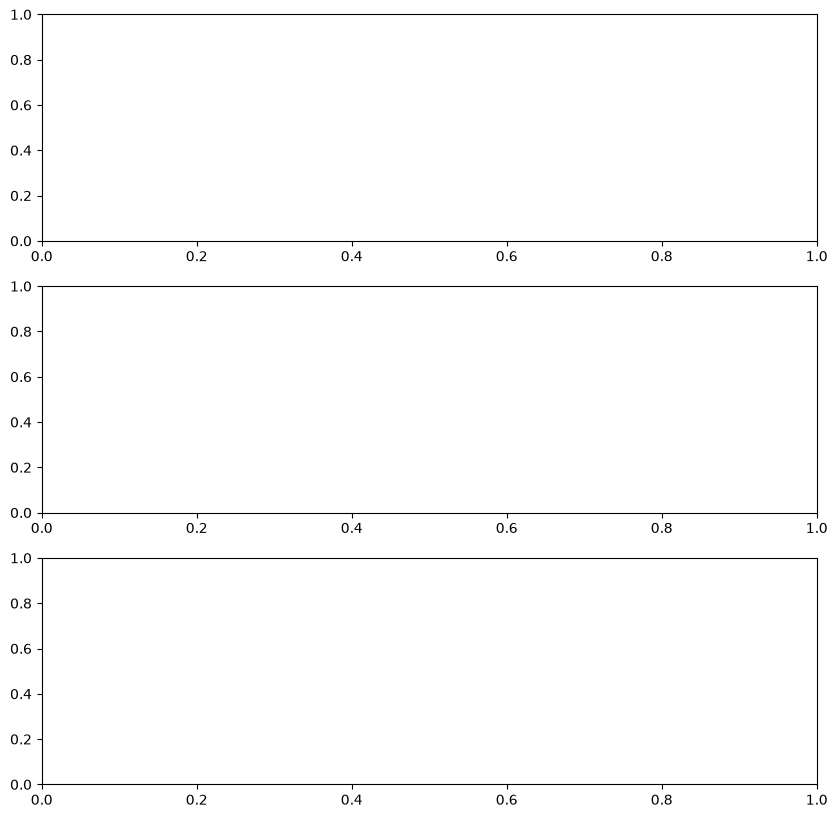

In [48]:
plt.figure(figsize=(10,10))
ax1 = plt.subplot(311)
ax2 = plt.subplot(312)
ax3 = plt.subplot(313)

for i in range(len(right_waist_accel_stances)):
    ax1.plot(right_waist_accel_stances[i], alpha = 0.25)

for i in range(len(right_vgrf_pred_stances_T)):
    ax2.plot(right_vgrf_pred_stances_T[i], alpha = 0.25)

for i in range(len(right_vgrf_stances_T)):
    ax3.plot(right_vgrf_stances_T[i], alpha = 0.25)

ax1.set_title('Right Waist Accel Stances')
ax2.set_title('Right vGRF Predicted Stances')
ax3.set_title('Right vGRF Reference Stances')

ax1.set_ylabel('g')
ax2.set_ylabel('BW')
ax3.set_ylabel('BW')

plt.tight_layout()

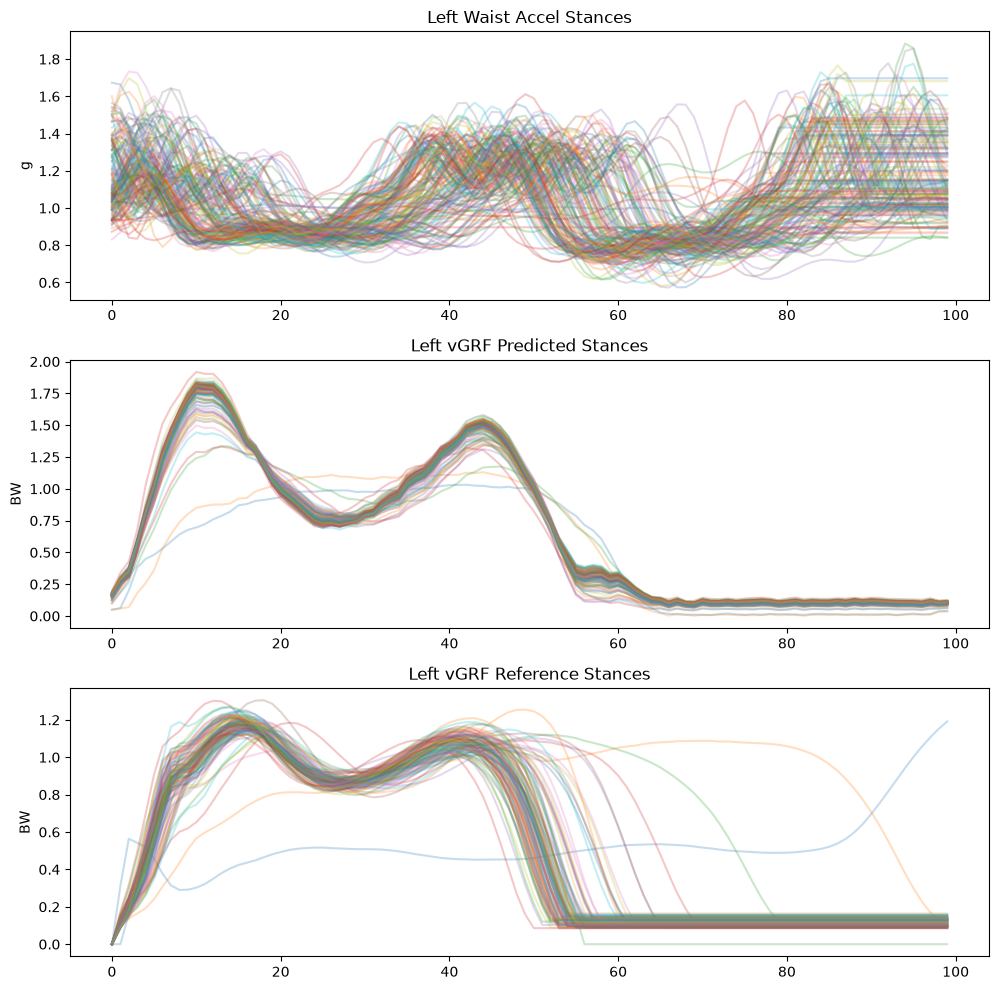

In [49]:
plt.figure(figsize=(10,10))
ax1 = plt.subplot(311)
ax2 = plt.subplot(312)
ax3 = plt.subplot(313)

for i in range(len(left_waist_accel_stances)):
    ax1.plot(left_waist_accel_stances[i], alpha = 0.25)

for i in range(len(left_vgrf_pred_stances_T)):
    ax2.plot(left_vgrf_pred_stances_T[i], alpha = 0.25)

for i in range(len(left_vgrf_stances_T)):
    ax3.plot(left_vgrf_stances_T[i], alpha = 0.25)

ax1.set_title('Left Waist Accel Stances')
ax2.set_title('Left vGRF Predicted Stances')
ax3.set_title('Left vGRF Reference Stances')

ax1.set_ylabel('g')
ax2.set_ylabel('BW')
ax3.set_ylabel('BW')

plt.tight_layout()

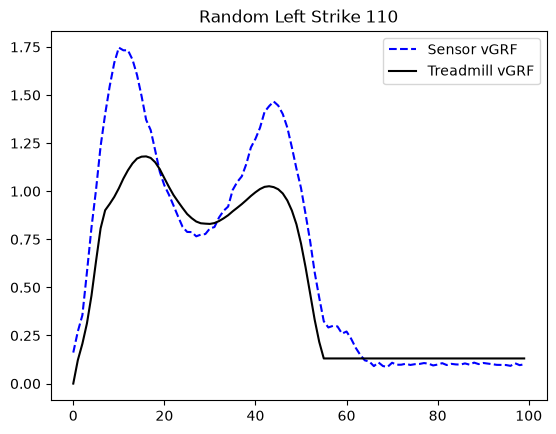

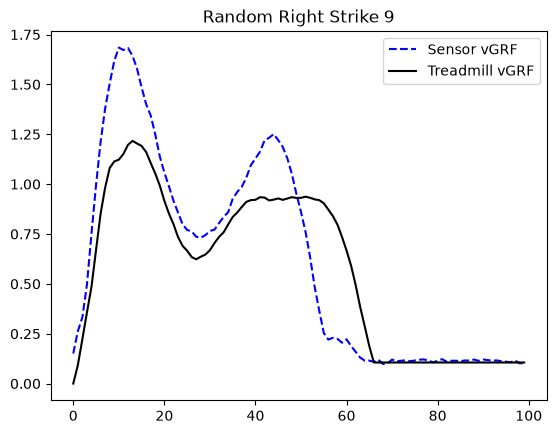

In [50]:
import numpy as np

random_index = np.random.randint(0, len(left_vgrf_pred_stances))


plt.plot(left_vgrf_pred_stances.T[random_index], color = "blue", linestyle = "--", label = "Sensor vGRF")
plt.plot(left_vgrf_stances.T[random_index], color = "black",  label = "Treadmill vGRF")
# plt.plot(left_accel_stances[random_index], color = "blue",  label = "Acceleration Signal")
plt.legend()
plt.title(f'Random Left Strike {random_index}')
plt.show()

random_index = np.random.randint(0, len(right_vgrf_pred_stances))

plt.plot(right_vgrf_pred_stances.T[random_index], color = "blue", linestyle = "--", label = "Sensor vGRF")
plt.plot(right_vgrf_stances.T[random_index], color = "black",  label = "Treadmill vGRF")
# plt.plot(left_accel_stances[random_index], color = "blue",  label = "Acceleration Signal")
plt.legend()
plt.title(f'Random Right Strike {random_index}')
plt.show()

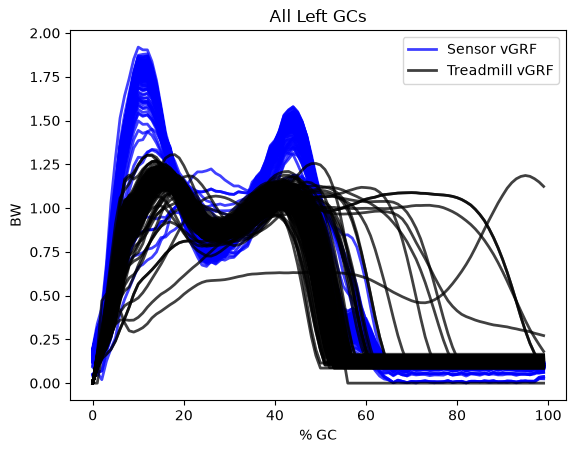

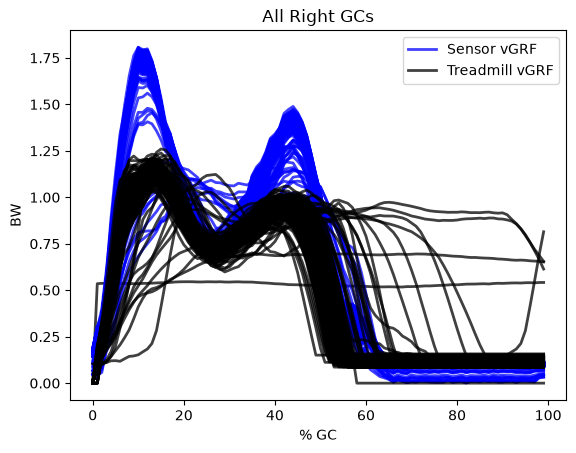

In [51]:
A1 = 0.75
LW1 = 2

plt.plot(left_vgrf_pred_stances.T.iloc[:,1], color = "blue", label = "Sensor vGRF", alpha = A1, lw=LW1)
plt.plot(left_vgrf_stances.T.iloc[:,1], color = "black",  label = "Treadmill vGRF", alpha = A1, lw=LW1)
plt.plot(left_vgrf_pred_stances.T.iloc[:,1:], color = "blue", alpha = A1, lw=LW1)
plt.plot(left_vgrf_stances.T.iloc[:,1:], color = "black", alpha = A1, lw=LW1)
plt.legend()
plt.title('All Left GCs')
plt.xlabel('% GC')
plt.ylabel('BW')
plt.show()

plt.plot(right_vgrf_pred_stances.T.iloc[:,0], color = "blue", label = "Sensor vGRF", alpha = A1, lw=LW1)
plt.plot(right_vgrf_stances.T.iloc[:,0], color = "black",  label = "Treadmill vGRF", alpha = A1, lw=LW1)
plt.plot(right_vgrf_pred_stances.T.iloc[:,1:], color = "blue", alpha = A1, lw=LW1)
plt.plot(right_vgrf_stances.T.iloc[:,1:], color = "black", alpha = A1, lw=LW1)
plt.legend()
plt.title('All Right GCs')
plt.xlabel('% GC')
plt.ylabel('BW')
plt.show()

In [ ]:
right_vgrf_stances

In [ ]:
from utils.stance import StanceAnalyzer
import matplotlib.pyplot as plt

analyzer = StanceAnalyzer() 
vgrf = treadmill.left_df['vgrf']  
start_idx, stances = analyzer.extract_treadmill_stances(vgrf)  

#vgrf
plt.figure(figsize=(10, 6))
for stance in stances:
    plt.plot(stance.values, alpha=0.6)
plt.title("Normalized vGRF")
plt.xlabel("Normalized Time (%)")
plt.ylabel("vGRF (Body Weight or N)")
plt.grid(True)
plt.tight_layout()
plt.show()


r_ankle = sensors.right_df['accel_filtered']
start_idx, stances = analyzer.extract_treadmill_stances(r_ankle)  
for stance in stances:
    plt.plot(stance.values, alpha=0.6)
plt.title("Right Ankle")
plt.xlabel("Normalized Time (%)")
plt.ylabel("g's")
plt.grid(True)
plt.tight_layout()
plt.show()

l_ankle = sensors.left_df['accel_filtered']
start_idx, stances = analyzer.extract_treadmill_stances(l_ankle)  
for stance in stances:
    plt.plot(stance.values, alpha=0.6)
plt.title("Left Ankle")
plt.xlabel("Normalized Time (%)")
plt.ylabel("g's")
plt.grid(True)
plt.tight_layout()
plt.show()

l_waist = sensors.waist_df['accel_filtered']
start_idx, stances = analyzer.extract_treadmill_stances(l_waist)  
for stance in stances:
    plt.plot(stance.values, alpha=0.6)
plt.title("Waist")
plt.xlabel("Normalized Time (%)")
plt.ylabel("g's")
plt.grid(True)
plt.tight_layout()
plt.show()